# Sampling-Based Inference in Discrete Bayesian Networks

Exact inference algorithms such as Variable Elimination and Belief
Propagation compute probabilities by manipulating factors directly.

These methods are exact, but their computational cost can become large
when the network contains many variables or when intermediate factors
have large scopes.

Sampling-based inference takes a different approach.

Instead of computing a probability exactly, it estimates the probability
from randomly generated samples.

This notebook develops the following methods:

1. Prior Sampling
2. Rejection Sampling
3. Likelihood Weighting
4. Importance Sampling
5. Gibbs Sampling

All methods will be tested on the same Bayesian Network and compared
against an exact posterior.

## Roadmap of Sampling-Based Inference

In the previous notebooks, we studied **exact inference** methods such as Variable Elimination and Belief Propagation. Although these methods compute the posterior distribution exactly, they become computationally expensive for large Bayesian Networks.

In this notebook, we study **sampling-based inference**, where probabilities are estimated from randomly generated samples.

The following roadmap shows how the sampling algorithms are connected.

```text
                        Bayesian Network
                               │
                               ▼
               How can we perform inference?
                               │
              ┌────────────────┴────────────────┐
              │                                 │
              ▼                                 ▼
      Exact Inference                 Approximate Inference
              │                                 │
      ┌───────┴────────┐                        │
      │                │                        ▼
      ▼                ▼                 Prior Sampling
Variable          Belief Propagation           │
Elimination                                   ▼
                                        Rejection Sampling
                                                │
                                                ▼
                                      Likelihood Weighting
                                                │
                                                ▼
                                       Importance Sampling
                                                │
                                                ▼
                                           Gibbs Sampling
```

In the remainder of this notebook, we focus on **Approximate Inference** and study how each sampling algorithm addresses the limitations of the previous one.

## 1. Monte Carlo Estimation

Suppose samples

$$
x^{(1)},x^{(2)},\ldots,x^{(N)}
$$

are drawn from the distribution of a discrete variable \(X\).

The probability of \(X=x\) can be estimated by

$$\widehat{P}_N(X=x)=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}\!\left[x^{(i)}=x\right].
$$

The indicator function equals one when the sampled value is \(x\), and zero otherwise.

As the number of samples increases, the empirical frequency approaches the true probability.

## 2. Bayesian Network Used in This Notebook

We use the following network for every sampling algorithm:

```text
Burglary      Earthquake
     \          /
      \        /
         Alarm
        /     \
       /       \
JohnCalls   MaryCalls
                |
          PoliceReport

### Implementation

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Hashable, Mapping

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [18]:
%%capture
%run "../../01_Representation/05_DiscreteFactor.ipynb"
%run "../../01_Representation/06_Bayesian_Networks.ipynb"
%run "../Exact_Inference/09_Variable_Elimination.ipynb"

In [19]:
binary_domain = [False, True]

In [20]:
factor_burglary = Factor(
    variables=["Burglary"],
    domains={
        "Burglary": binary_domain,
    },
    values=np.array([
        0.999,
        0.001,
    ]),
    name="P(Burglary)",
)

factor_earthquake = Factor(
    variables=["Earthquake"],
    domains={
        "Earthquake": binary_domain,
    },
    values=np.array([
        0.998,
        0.002,
    ]),
    name="P(Earthquake)",
)

factor_alarm = Factor(
    variables=[
        "Burglary",
        "Earthquake",
        "Alarm",
    ],
    domains={
        "Burglary": binary_domain,
        "Earthquake": binary_domain,
        "Alarm": binary_domain,
    },
    values=np.array([
        [
            [0.999, 0.001],
            [0.710, 0.290],
        ],
        [
            [0.060, 0.940],
            [0.050, 0.950],
        ],
    ]),
    name="P(Alarm|Burglary,Earthquake)",
)

factor_john_calls = Factor(
    variables=["Alarm", "JohnCalls"],
    domains={
        "Alarm": binary_domain,
        "JohnCalls": binary_domain,
    },
    values=np.array([
        [0.95, 0.05],
        [0.10, 0.90],
    ]),
    name="P(JohnCalls|Alarm)",
)

factor_mary_calls = Factor(
    variables=["Alarm", "MaryCalls"],
    domains={
        "Alarm": binary_domain,
        "MaryCalls": binary_domain,
    },
    values=np.array([
        [0.99, 0.01],
        [0.30, 0.70],
    ]),
    name="P(MaryCalls|Alarm)",
)

factor_police_report = Factor(
    variables=["MaryCalls", "PoliceReport"],
    domains={
        "MaryCalls": binary_domain,
        "PoliceReport": binary_domain,
    },
    values=np.array([
        [0.995, 0.005],
        [0.20, 0.80],
    ]),
    name="P(PoliceReport|MaryCalls)",
)

In [21]:
alarm_network = BayesianNetwork(
    domains={
        "Burglary": binary_domain,
        "Earthquake": binary_domain,
        "Alarm": binary_domain,
        "JohnCalls": binary_domain,
        "MaryCalls": binary_domain,
        "PoliceReport": binary_domain,
    },
    name="Alarm Network",
)

alarm_network.add_edge("Burglary", "Alarm")
alarm_network.add_edge("Earthquake", "Alarm")
alarm_network.add_edge("Alarm", "JohnCalls")
alarm_network.add_edge("Alarm", "MaryCalls")
alarm_network.add_edge("MaryCalls", "PoliceReport")

alarm_network.set_cpt(
    "Burglary",
    factor_burglary,
)

alarm_network.set_cpt(
    "Earthquake",
    factor_earthquake,
)

alarm_network.set_cpt(
    "Alarm",
    factor_alarm,
)

alarm_network.set_cpt(
    "JohnCalls",
    factor_john_calls,
)

alarm_network.set_cpt(
    "MaryCalls",
    factor_mary_calls,
)

alarm_network.set_cpt(
    "PoliceReport",
    factor_police_report,
)

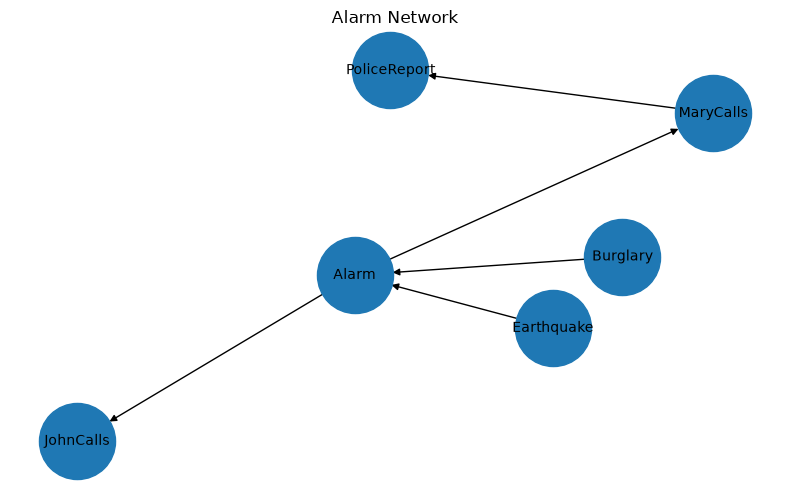

In [23]:
alarm_network.plot()

In [24]:
print(
    list(
        nx.topological_sort(
            alarm_network.graph
        )
    )
)

['Burglary', 'Earthquake', 'Alarm', 'JohnCalls', 'MaryCalls', 'PoliceReport']


## 3. Prior Sampling

### Motivation

In the previous notebook, we studied **exact inference** algorithms such as Variable Elimination and Belief Propagation, which compute posterior probabilities exactly.

Approximate inference follows a different philosophy. Instead of computing probabilities analytically, it estimates them from randomly generated samples.

The first question we need to answer is:

> **How can we generate samples from a Bayesian Network according to its joint probability distribution?**

Prior Sampling answers this question by generating complete assignments (possible worlds) that follow the probability distribution represented by the Bayesian Network.

For the Alarm Network, the joint distribution is

$$P(B,E,A,J,M,R)=
P(B)
P(E)
P(A\mid B,E)
P(J\mid A)
P(M\mid A)
P(R\mid M).
$$

Each generated sample represents one possible world drawn from this joint distribution.

---

### Flowchart

```text
                 Bayesian Network
                        │
                        ▼
             Topological Ordering
                        │
                        ▼
          Sample Root Variables
           P(B), P(E), ...
                        │
                        ▼
      Sample Child Variables
   P(A|B,E), P(J|A), ...
                        │
                        ▼
        Complete Assignment
          (One Possible World)
                        │
                        ▼
      Repeat N Times to Obtain
       Samples from the Joint
      Probability Distribution
```

---


### Mathematics

A Bayesian Network factorizes the joint probability distribution as

$$P(X_1,X_2,\ldots,X_n)=
\prod_{i=1}^{n}
P(X_i\mid Pa(X_i)),
$$

where $Pa(X_i)$ denotes the set of parent variables of $X_i$.

Prior Sampling follows exactly this factorization.

Variables are sampled in **topological order**, ensuring that every parent variable has already been sampled before its child.

For the Alarm Network, one valid ordering is

$$
B
\rightarrow
E
\rightarrow
A
\rightarrow
J
\rightarrow
M
\rightarrow
R.
$$

The sampling process therefore becomes

$$
\begin{aligned}
B &\sim P(B),\\
E &\sim P(E),\\
A &\sim P(A\mid B,E),\\
J &\sim P(J\mid A),\\
M &\sim P(M\mid A),\\
R &\sim P(R\mid M).
\end{aligned}
$$

After all variables have been sampled, one complete assignment is obtained.

Repeating this procedure generates samples from the joint distribution

$$
P(B,E,A,J,M,R).
$$

---

### Algorithm

```text
Input:
    Bayesian Network
    Number of samples N

For each sample:

    Sample variables in topological order.

    Root variables are sampled from their prior distributions.

    Child variables are sampled from their
    conditional probability tables using the
    already sampled parent values.

    Store the completed assignment.

Return all generated samples.
```

---

### Implementation

In [28]:
rng = np.random.default_rng(42)

samples = alarm_network.sample(
    size=100_00,
    rng=rng,
)

In [29]:
for variable in alarm_network.topological_order():
    count_true = sum(
        sample[variable] is True
        for sample in samples
    )

    print(
        variable,
        count_true,
        count_true / len(samples),
    )

Burglary 13 0.0013
Earthquake 23 0.0023
Alarm 24 0.0024
JohnCalls 543 0.0543
MaryCalls 117 0.0117
PoliceReport 149 0.0149


### Experiment

Generate multiple samples from the Alarm Network.

Observe that every generated sample is a complete assignment of all variables.

Example:

| Burglary | Earthquake | Alarm | JohnCalls | MaryCalls | PoliceReport |
|----------|------------|-------|-----------|-----------|--------------|
| False | False | False | False | False | False |
| False | True | True | True | True | True |
| True | False | True | True | False | False |

As the number of generated samples increases, the empirical distribution converges to the true joint distribution represented by the Bayesian Network.

---

### Discussion

#### Advantages

- Simple and intuitive.
- Generates samples directly from the Bayesian Network.
- Forms the foundation of many approximate inference algorithms.

#### Disadvantages

- Generates samples only from the joint distribution.
- Does not directly answer conditional probability queries.
- Rare events occur infrequently and therefore require many samples to estimate accurately.

---

### Limitations

#### 1. Does not estimate posterior distributions

Prior Sampling estimates the joint distribution

$$
P(X_1,X_2,\ldots,X_n),
$$

but our primary inference task is usually

$$
P(Q\mid e),
$$

where &e& denotes observed evidence.

Prior Sampling does not utilize evidence and therefore cannot directly estimate posterior probabilities.

---

#### 2. Rare events require many samples

Events with very small probabilities occur infrequently in the generated samples.

For example, if

$$
P(B=\mathrm{True})=0.001,
$$

then only a small number of generated samples will contain a burglary event.

Estimating probabilities involving rare events therefore requires a large number of samples.

---

### Motivation for the Next Algorithm

Although Prior Sampling successfully generates samples from the joint distribution, it ignores the observed evidence.

This naturally raises the following question:

> **How can we estimate the posterior distribution $P(Q\mid e)$ using the generated samples?**

One simple idea is to generate many samples and **keep only those that agree with the observed evidence**.

This leads to the next algorithm, **Rejection Sampling**.

```text
Question
How can we generate samples
from a Bayesian Network?
            │
            ▼
     Prior Sampling
            │
            ▼
Limitation
Cannot estimate P(Q | e)
directly.
            │
            ▼
Question
How can we estimate
P(Q | e)?
            │
            ▼
  Rejection Sampling
```

## 4. Rejection Sampling

### Motivation

Prior Sampling generates samples from the joint distribution represented by a Bayesian Network. However, our objective is usually to compute a **posterior distribution**

$$
P(Q \mid e),
$$

where

- \(Q\) is the query variable.
- \(e\) is the observed evidence.

For example, in the Alarm Network our goal is to estimate

$$
P(B=\mathrm{True}\mid
J=\mathrm{True},
M=\mathrm{True},
R=\mathrm{True}).
$$

Prior Sampling generates many possible worlds, but most of them do not satisfy the observed evidence. Rejection Sampling addresses this problem by keeping only the samples that agree with the evidence.

---

### Flowchart

```text
                    Bayesian Network
                           │
                           ▼
                  Prior Sampling
                           │
            Generate Complete Samples
                           │
                           ▼
          +-----------------------------+
          | Does the sample satisfy     |
          | the observed evidence?      |
          +-----------------------------+
                  │             │
                Yes             No
                  │             │
                  ▼             ▼
           Keep Sample     Reject Sample
                  │
                  ▼
       Estimate Posterior Distribution
                  │
                  ▼
             P(Q = q | e)
```

---

### Mathematics

Suppose we generate \(N\) samples from the Bayesian Network.

Let

- \(N(E=e)\) be the number of samples that satisfy the evidence.
- \(N(Q=q,E=e)\) be the number of accepted samples in which the query variable also takes the value \(q\).

The posterior distribution is estimated as

$$
P(Q=q\mid E=e)
\approx
\frac{
N(Q=q,E=e)
}{
N(E=e)
}.
$$

Unlike Prior Sampling, only the accepted samples contribute to the posterior estimate.

---

### Algorithm

```text
Input:
    Bayesian Network
    Query variable Q
    Evidence e
    Number of samples N

Generate N prior samples.

For each sample:

    If the sample satisfies the evidence:
        Keep the sample.

    Otherwise:
        Reject the sample.

Estimate the posterior distribution
using only the accepted samples.
```

---

### Implementation

In [31]:
from typing import Hashable, Mapping


def matches_evidence(
    sample: Mapping[str, Hashable],
    evidence: Mapping[str, Hashable],
) -> bool:
    """
    Return True if a sample agrees with all evidence variables.
    """

    return all(
        sample[variable] == value
        for variable, value in evidence.items()
    )

In [32]:
sample = {
    "Burglary": False,
    "Earthquake": False,
    "Alarm": True,
    "JohnCalls": True,
    "MaryCalls": True,
    "PoliceReport": True,
}

evidence = {
    "JohnCalls": True,
    "MaryCalls": True,
    "PoliceReport": True,
}

matches_evidence(
    sample,
    evidence,
)

True

In [33]:
def rejection_sampling(
    network: BayesianNetwork,
    query_variable: str,
    evidence: Mapping[str, Hashable],
    number_of_samples: int,
    rng: np.random.Generator | None = None,
) -> dict[Hashable, float]:
    """
    Estimate P(query_variable | evidence) using rejection sampling.
    """

    if rng is None:
        rng = np.random.default_rng()

    samples = network.sample(
        size=number_of_samples,
        rng=rng,
    )

    accepted_samples = [
        sample
        for sample in samples
        if matches_evidence(
            sample,
            evidence,
        )
    ]

    if len(accepted_samples) == 0:
        raise ValueError(
            "No samples matched the evidence."
        )

    domain = network.domains[
        query_variable
    ]

    counts = {
        value: 0
        for value in domain
    }

    for sample in accepted_samples:
        counts[
            sample[query_variable]
        ] += 1

    number_of_accepted_samples = len(
        accepted_samples
    )

    posterior = {
        value: (
            counts[value]
            / number_of_accepted_samples
        )
        for value in domain
    }

    return posterior

### Experiment

We estimate

$$
P(B=\mathrm{True}\mid
J=\mathrm{True},
M=\mathrm{True},
R=\mathrm{True})
$$

using Rejection Sampling and compare the estimated posterior with the exact posterior obtained using Variable Elimination.

In addition to the posterior estimate, we also compute the **acceptance rate**

$$\text{Acceptance Rate}=
\frac{
\text{Number of Accepted Samples}
}{
\text{Total Number of Generated Samples}
}.
$$

The acceptance rate provides an indication of how efficiently the algorithm utilizes the generated samples.

---

In [34]:
evidence = {
    "JohnCalls": True,
    "MaryCalls": True,
    "PoliceReport": True,
}

posterior = rejection_sampling(
    network=alarm_network,
    query_variable="Burglary",
    evidence=evidence,
    number_of_samples=100_000,
    rng=np.random.default_rng(42),
)

posterior

{False: 0.6875, True: 0.3125}

In [35]:
samples = alarm_network.sample(
    size=100_000,
    rng=np.random.default_rng(42),
)

accepted_samples = [
    sample
    for sample in samples
    if matches_evidence(
        sample,
        evidence,
    )
]

acceptance_rate = (
    len(accepted_samples)
    / len(samples)
)

print(
    "Accepted samples:",
    len(accepted_samples),
)

print(
    "Acceptance rate:",
    acceptance_rate,
)

Accepted samples: 176
Acceptance rate: 0.00176


### Discussion

#### Advantages

- Very easy to understand and implement.
- Naturally extends Prior Sampling to answer conditional probability queries.
- Produces unbiased estimates as the number of samples increases.

#### Disadvantages

- Generates many samples that never contribute to the final estimate.
- Computational effort is wasted on rejected samples.
- Performance deteriorates rapidly when the observed evidence is rare.

### Limitations

#### 1. Rare events are poorly represented

Prior Sampling generates samples according to the joint distribution of the Bayesian Network.

If an event has a very small probability, such as

$$
P(B=\mathrm{True})=0.001,
$$

only a few generated samples will contain that event. Consequently, estimating probabilities involving rare events requires a large number of samples.

---

#### 2. Most generated samples are discarded

Every sample is generated completely before checking whether it satisfies the evidence.

```text
Generate Sample
       │
       ▼
Check Evidence
       │
   ┌───┴───┐
   │       │
Accept   Reject
```

If the evidence does not match, the entire sample is discarded even though computational effort has already been spent generating it.

---

#### 3. Inefficient for rare evidence

When the evidence is unlikely, only a very small fraction of generated samples are accepted.

```text
100000 Generated Samples
          │
          ▼
    99985 Rejected
          │
          ▼
      15 Accepted
```

As a result, a large amount of computation is wasted generating samples that never contribute to the posterior estimate.

---

### Motivation for the Next Algorithm

The main weakness of Rejection Sampling is that it **waits until a complete sample has been generated before checking the evidence**.

This naturally raises the following question:

> **Can we force the evidence to be true during sampling instead of generating and rejecting complete samples?**

This idea leads to the next algorithm, **Likelihood Weighting**, where evidence variables are fixed before sampling begins and every generated sample contributes to the posterior estimate by assigning it an appropriate weight.

```text
Prior Sampling
       │
       ▼
Cannot answer conditional queries
       │
       ▼
Rejection Sampling
       │
       ▼
Too many generated samples are rejected
       │
       ▼
Likelihood Weighting
```

## 5. Likelihood Weighting

### Motivation

Rejection Sampling estimates

$$
P(Q\mid e)
$$

by generating prior samples and discarding every sample that does not match the observed evidence.

This becomes inefficient when the evidence is rare because most generated samples are rejected.

This raises the next question:

> **Can we force the evidence to be true during sampling so that every generated sample remains useful?**

Likelihood Weighting does exactly this.

Instead of sampling evidence variables, their observed values are fixed. The remaining variables are sampled normally.

Because the evidence variables are no longer sampled, each generated sample is assigned a **weight** that represents how likely the observed evidence is under that sample.

---

### Flowchart

```text
                 Bayesian Network
                        │
                        ▼
              Topological Order
                        │
                        ▼
             For Each Variable
                        │
              ┌─────────┴─────────┐
              │                   │
              ▼                   ▼
      Is Evidence Variable?      No
              │                   │
             Yes                  ▼
              │            Sample Variable
              ▼            from its CPT
     Fix Observed Value
              │
              ▼
   Multiply Sample Weight
   by Evidence Likelihood
              │
              └─────────┬─────────┘
                        ▼
               Continue Sampling
                        │
                        ▼
           Complete Weighted Sample
                        │
                        ▼
               Repeat N Times
                        │
                        ▼
      Normalize Weighted Query Counts
                        │
                        ▼
                   P(Q | e)
```

---

### Mathematics

Suppose the evidence is

$$
E=e.
$$

Likelihood Weighting generates samples only for the non-evidence variables.

Each sample receives a weight

$$w=
\prod_{E_i\in E}
P(E_i=e_i\mid Pa(E_i)).
$$

The posterior is then estimated using weighted counts:

$$
P(Q=q\mid e)
\approx
\frac{
\sum_{i=1}^{N}
w^{(i)}
\mathbf{1}\!\left[Q^{(i)}=q\right]
}{
\sum_{i=1}^{N}
w^{(i)}
}.
$$

The main difference from Rejection Sampling is that **no sample is discarded**.

---

#### Example

Suppose the evidence is

$$
J=\mathrm{True},
\qquad
M=\mathrm{True},
\qquad
R=\mathrm{True}.
$$

During sampling:

- `JohnCalls` is fixed to `True`.
- `MaryCalls` is fixed to `True`.
- `PoliceReport` is fixed to `True`.

The remaining variables are sampled normally.

For one sampled world, suppose

```text
Burglary   = False
Earthquake = False
Alarm      = True
```

Then the sample weight becomes

$$w=
P(J=\mathrm{True}\mid A=\mathrm{True})
\,
P(M=\mathrm{True}\mid A=\mathrm{True})
\,
P(R=\mathrm{True}\mid M=\mathrm{True}).
$$

The sample is never rejected. Its influence on the final posterior depends on this weight.

<span style="color:red;">**Given the world I sampled, how plausible is the evidence I actually observed?** </span>


---

### Algorithm

```text
Input:
    Bayesian Network
    Query variable Q
    Evidence e
    Number of samples N

Initialize weighted counts for Q.

Repeat N times:

    weight = 1

    For each variable in topological order:

        If variable is evidence:

            Fix it to the observed value.

            Multiply weight by the probability
            of that evidence value given its parents.

        Otherwise:

            Sample normally from the variable's CPT.

    Add the sample weight to the count
    corresponding to the sampled value of Q.

Normalize all weighted counts.

Return the estimated posterior.
```

---

### Implementation

The first useful helper is a function that generates **one weighted sample**.


In [37]:
def likelihood_weighted_sample(
    network: BayesianNetwork,
    evidence: Mapping[str, Hashable],
    rng: np.random.Generator | None = None,
) -> tuple[dict[str, Hashable], float]:
    """
    Generate one likelihood-weighted sample.

    Evidence variables are fixed to their observed values.
    Non-evidence variables are sampled normally.

    Returns
    -------
    assignment:
        Complete variable assignment.

    weight:
        Likelihood weight of the observed evidence.
    """

    if rng is None:
        rng = np.random.default_rng()

    assignment = {}
    weight = 1.0

    for variable in network.topological_order():
        cpt = network.cpts[variable]
        parent_variables = network.parents(variable)

        parent_assignment = {
            parent: assignment[parent]
            for parent in parent_variables
        }

        if parent_variables:
            reduced_cpt = cpt.reduce(
                parent_assignment
            )
        else:
            reduced_cpt = cpt

        if variable in evidence:
            observed_value = evidence[variable]

            assignment[variable] = observed_value

            weight *= reduced_cpt.get_value(
                {
                    variable: observed_value,
                }
            )

        else:
            probabilities = np.asarray(
                reduced_cpt.values,
                dtype=float,
            )

            sampled_index = rng.choice(
                len(network.domains[variable]),
                p=probabilities,
            )

            assignment[variable] = (
                network.domains[variable][sampled_index]
            )

    return assignment, weight

In [38]:
def likelihood_weighting(
    network: BayesianNetwork,
    query_variable: str,
    evidence: Mapping[str, Hashable],
    number_of_samples: int,
    rng: np.random.Generator | None = None,
) -> dict[Hashable, float]:
    """
    Estimate P(query_variable | evidence)
    using likelihood weighting.
    """

    if rng is None:
        rng = np.random.default_rng()

    weighted_counts = {
        value: 0.0
        for value in network.domains[query_variable]
    }

    for _ in range(number_of_samples):
        sample, weight = likelihood_weighted_sample(
            network=network,
            evidence=evidence,
            rng=rng,
        )

        query_value = sample[query_variable]

        weighted_counts[query_value] += weight

    total_weight = sum(
        weighted_counts.values()
    )

    if total_weight == 0.0:
        raise ValueError(
            "Total sample weight is zero."
        )

    return {
        value: weighted_counts[value] / total_weight
        for value in network.domains[query_variable]
    }

### Experiment

Use the same evidence as in Rejection Sampling.

In [39]:
evidence = {
    "JohnCalls": True,
    "MaryCalls": True,
    "PoliceReport": True,
}

In [44]:
posterior_lw = likelihood_weighting(
    network=alarm_network,
    query_variable="Earthquake",
    evidence=evidence,
    number_of_samples=100_000,
    rng=np.random.default_rng(42),
)

posterior_lw

{False: 0.841001802963292, True: 0.15899819703670803}

Now compare this result with:

- Rejection Sampling
- Exact inference using Variable Elimination

The estimates should approach the same posterior as the number of samples increases.

---


### Inspecting a Single Weighted Sample

It is useful to inspect one sample directly:


In [41]:
sample, weight = likelihood_weighted_sample(
    network=alarm_network,
    evidence=evidence,
    rng=np.random.default_rng(42),
)

print(sample)
print("Weight:", weight)

{'Burglary': False, 'Earthquake': False, 'Alarm': False, 'JohnCalls': True, 'MaryCalls': True, 'PoliceReport': True}
Weight: 0.0004


Notice that the evidence variables are always fixed to

```text
JohnCalls     = True
MaryCalls     = True
PoliceReport  = True
```

Only the non-evidence variables are sampled.

---

### Discussion

#### Advantages

- No generated samples are rejected.
- More efficient than Rejection Sampling when evidence is rare.
- Easy to implement using the same ancestral-sampling structure as Prior Sampling.

#### Disadvantages

- Samples can have very different weights.
- A small number of high-weight samples may dominate the estimate.
- Performance becomes worse when there are many evidence variables or when the evidence is far downstream in the network.

---

### Limitations

The main weakness of Likelihood Weighting is **weight degeneracy**.

Suppose several evidence variables are present.

The sample weight is

$$w=
\prod_{E_i\in E}
P(E_i=e_i\mid Pa(E_i)).
$$

If several of these probabilities are small, their product can become extremely small.

For example,

$$w=0.1
\times
0.05
\times
0.02
=0.0001.
$$

Many samples may therefore receive almost no influence on the final estimate.

Although every sample is technically retained, only a few high-weight samples may contribute significantly.

```text
Generated Samples
       │
       ▼
All Samples Are Kept
       │
       ▼
Different Sample Weights
       │
       ├── Large Weight  ──► Strong Contribution
       │
       ├── Small Weight  ──► Weak Contribution
       │
       └── Tiny Weight   ──► Almost No Contribution
```

So Likelihood Weighting solves the **sample rejection problem**, but not necessarily the **sample efficiency problem**.

---

### Motivation for the Next Algorithm

Likelihood Weighting still samples non-evidence variables using the original Bayesian Network distribution.

This may generate many samples in regions that contribute very little to the posterior.

This raises the next question:

> **Can we choose a different sampling distribution that generates more useful samples?**

This leads to **Importance Sampling**.

```text
Question
Can we avoid rejecting samples?
            │
            ▼
 Likelihood Weighting
            │
            ▼
Limitation
Some samples receive
extremely small weights.
            │
            ▼
Question
Can we sample from a
better distribution?
            │
            ▼
 Importance Sampling
```

## 6. Importance Sampling

### Motivation

Likelihood Weighting improves upon Rejection Sampling by keeping every generated sample. However, the generated samples are still drawn according to the original Bayesian Network.

As a result, many samples may receive extremely small weights and contribute very little to the final posterior estimate.

This naturally raises the following question:

> **Can we generate samples from a distribution that produces more informative samples for our inference problem?**

Importance Sampling answers this question by allowing us to sample from a different probability distribution, called the **proposal distribution**.

Unlike Likelihood Weighting, which always samples from the Bayesian Network, Importance Sampling lets us choose where to generate samples while correcting any bias introduced by this choice.


---

### Flowchart

```text
              Target Distribution
                  P(X | e)
                      │
                      │
      Difficult to sample directly
                      │
                      ▼
         Choose Proposal Distribution
                   q(X)
                      │
                      ▼
          Generate Sample from q(X)
                      │
                      ▼
      Compute Importance Weight

              P(X)
        w = --------
              q(X)

                      │
                      ▼
      Weighted Posterior Estimate
```

---

### Intuition

Until now, every sampling algorithm has generated samples according to the Bayesian Network.

Suppose the Bayesian Network rarely generates burglary events.

```text
Bayesian Network

Burglary = True

↓

Very Rare
```

However, our query is

$$
P(Burglary \mid J=True,M=True,R=True).
$$

For this query, worlds containing burglaries are much more informative than worlds without burglaries.

Instead of waiting for the Bayesian Network to generate these informative samples, Importance Sampling intentionally samples them more frequently.

Because these samples are generated from a different distribution, each sample must be corrected using an importance weight.

In other words,

> **Importance Sampling deliberately changes where it samples and then mathematically compensates for that change.**

---

#### One Sample

Suppose we decide to use a proposal distribution that generates burglaries more often.

Instead of

$$
P(B=True)=0.001,
$$

our proposal distribution chooses

$$
q(B=True)=0.30.
$$

Now we generate

```text
B = True
E = False
A = True
J = True
M = True
R = True
```

This sample is much more useful for estimating

$$
P(B\mid e).
$$

However, because burglaries were intentionally oversampled, this sample should not contribute as if it had been generated from the original Bayesian Network.

Its contribution is corrected using

$$w=
\frac{P(x)}
     {q(x)},
$$

where

- $P(x)$ is the probability under the Bayesian Network.
- $q(x)$ is the probability under the proposal distribution.

The weight removes the bias introduced by sampling from the proposal distribution.

---

### Mathematics

Suppose

- $P(x)$ is the target distribution.
- $q(x)$ is the proposal distribution.

Samples are generated from

$$
x^{(i)}
\sim
q(x).
$$

Each sample receives the importance weight

$$w^{(i)}=
\frac{
P(x^{(i)})
}{
q(x^{(i)})
}.
$$

The posterior is estimated as

$$
P(Q=q\mid e)
\approx
\frac{
\sum_i
w^{(i)}
\mathbf{1}[Q^{(i)}=q]
}{
\sum_i
w^{(i)}
}.
$$

---

### Algorithm

```text
Input:
    Target distribution P(X)
    Proposal distribution q(X)

Repeat N times:

    Generate one sample from q(X).

    Compute

        weight = P(sample) / q(sample)

    Add the weighted sample
    to the posterior estimate.

Normalize the weighted counts.

Return the posterior distribution.
```

### Implementation

In [45]:
assignment = {
    "Burglary": False,
    "Earthquake": False,
    "Alarm": False,
    "JohnCalls": False,
    "MaryCalls": False,
    "PoliceReport": False,
}

In [46]:
p = alarm_network.probability(
    assignment
)

print(p)

0.9320589871159048


In [47]:
p_manual = (
    factor_burglary.get_value({
        "Burglary": False,
    })
    *
    factor_earthquake.get_value({
        "Earthquake": False,
    })
    *
    factor_alarm.get_value({
        "Burglary": False,
        "Earthquake": False,
        "Alarm": False,
    })
    *
    factor_john_calls.get_value({
        "Alarm": False,
        "JohnCalls": False,
    })
    *
    factor_mary_calls.get_value({
        "Alarm": False,
        "MaryCalls": False,
    })
    *
    factor_police_report.get_value({
        "MaryCalls": False,
        "PoliceReport": False,
    })
)

print(p_manual)

print(
    np.isclose(
        p,
        p_manual,
    )
)

0.9320589871159048
True


#### Create an Abstract Base Class

In [48]:
from __future__ import annotations

from abc import ABC, abstractmethod
from typing import Hashable, Mapping

import numpy as np


class ProposalDistribution(ABC):
    """
    Base class for proposal distributions used in
    Importance Sampling.
    """

    @abstractmethod
    def sample(
        self,
        rng: np.random.Generator | None = None,
    ) -> dict[str, Hashable]:
        """
        Generate one sample from the proposal
        distribution.
        """
        raise NotImplementedError

    @abstractmethod
    def probability(
        self,
        assignment: Mapping[str, Hashable],
    ) -> float:
        """
        Evaluate q(x) for a complete assignment.
        """
        raise NotImplementedError

#### Simplest proposal

In [50]:
class BayesianNetworkProposal(
    ProposalDistribution,
):
    """
    Proposal distribution that samples directly
    from a Bayesian Network.
    """

    def __init__(
        self,
        network: BayesianNetwork,
    ):
        self.network = network

    def sample(
        self,
        rng: np.random.Generator | None = None,
    ) -> dict[str, Hashable]:

        return self.network.sample(
            size=1,
            rng=rng,
        )[0]

    def probability(
        self,
        assignment,
    ) -> float:

        return self.network.probability(
            assignment,
        )

In [51]:
def importance_sample(
    network: BayesianNetwork,
    proposal: ProposalDistribution,
    rng: np.random.Generator | None = None,
) -> tuple[dict[str, Hashable], float]:
    """
    Generate one importance sample.

    The sample is drawn from the proposal distribution q(x),
    and its importance weight is

        w(x) = P(x) / q(x)

    Parameters
    ----------
    network:
        Bayesian Network representing the target distribution P(x).

    proposal:
        Proposal distribution q(x).

    rng:
        Random number generator.

    Returns
    -------
    sample:
        One complete assignment generated from q(x).

    weight:
        Importance weight P(x) / q(x).
    """

    if rng is None:
        rng = np.random.default_rng()

    sample = proposal.sample(
        rng=rng,
    )

    target_probability = network.probability(
        sample,
    )

    proposal_probability = proposal.probability(
        sample,
    )

    if proposal_probability <= 0.0:
        raise ValueError(
            "The proposal probability must be greater than zero "
            "for every generated sample."
        )

    weight = (
        target_probability
        / proposal_probability
    )

    return sample, weight

In [52]:
proposal = BayesianNetworkProposal(
    alarm_network
)

In [53]:
sample, weight = importance_sample(
    network=alarm_network,
    proposal=proposal,
    rng=np.random.default_rng(42),
)

print("Sample:")
print(sample)

print("\nWeight:")
print(weight)

Sample:
{'Burglary': False, 'Earthquake': False, 'Alarm': False, 'JohnCalls': False, 'MaryCalls': False, 'PoliceReport': False}

Weight:
1.0


In [54]:
def importance_sampling(
    network: BayesianNetwork,
    proposal: ProposalDistribution,
    query_variable: str,
    number_of_samples: int,
    rng: np.random.Generator | None = None,
) -> dict[Hashable, float]:
    """
    Estimate the marginal distribution of a query variable
    using Importance Sampling.
    """

    if rng is None:
        rng = np.random.default_rng()

    weighted_counts = {
        value: 0.0
        for value in network.domains[query_variable]
    }

    for _ in range(number_of_samples):
        sample, weight = importance_sample(
            network=network,
            proposal=proposal,
            rng=rng,
        )

        query_value = sample[query_variable]

        weighted_counts[query_value] += weight

    total_weight = sum(
        weighted_counts.values()
    )

    if total_weight <= 0.0:
        raise ValueError(
            "The total importance weight must be greater than zero."
        )

    return {
        value: weighted_counts[value] / total_weight
        for value in network.domains[query_variable]
    }

In [55]:
proposal = BayesianNetworkProposal(
    alarm_network
)

estimate = importance_sampling(
    network=alarm_network,
    proposal=proposal,
    query_variable="Burglary",
    number_of_samples=100_000,
    rng=np.random.default_rng(42),
)

estimate

{False: 0.99896, True: 0.00104}

In [64]:
from __future__ import annotations

from typing import Hashable, Mapping

import numpy as np


class AlarmProposal(
    ProposalDistribution,
):
    """
    Proposal distribution for the Alarm Network.

    The proposal modifies only the Burglary prior to generate
    burglary events more frequently.

    All remaining variables are sampled according to the
    Bayesian Network.
    """

    def __init__(
        self,
        network: BayesianNetwork,
        burglary_probability: float = 0.30,
    ):
        self.network = network
        self.burglary_probability = burglary_probability

    def sample(
        self,
        rng: np.random.Generator | None = None,
    ) -> dict[str, Hashable]:

        if rng is None:
            rng = np.random.default_rng()

        assignment = {}

        for variable in self.network.topological_order():

            if variable == "Burglary":

                probabilities = np.array(
                    [
                        1.0 - self.burglary_probability,
                        self.burglary_probability,
                    ]
                )

            else:

                cpt = self.network.cpts[variable]

                parent_variables = self.network.parents(
                    variable
                )

                if parent_variables:
                    reduced_cpt = cpt.reduce(
                        {
                            parent: assignment[parent]
                            for parent in parent_variables
                        }
                    )
                else:
                    reduced_cpt = cpt

                probabilities = np.asarray(
                    reduced_cpt.values,
                    dtype=float,
                )

            sampled_index = rng.choice(
                len(self.network.domains[variable]),
                p=probabilities,
            )

            assignment[variable] = (
                self.network.domains[variable][sampled_index]
            )

        return assignment

    def probability(
        self,
        assignment: Mapping[str, Hashable],
    ) -> float:

        probability = 1.0

        for variable in self.network.topological_order():

            if variable == "Burglary":

                if assignment["Burglary"]:

                    probability *= (
                        self.burglary_probability
                    )

                else:

                    probability *= (
                        1.0
                        - self.burglary_probability
                    )

            else:

                cpt = self.network.cpts[variable]

                local_assignment = {
                    variable_name: assignment[
                        variable_name
                    ]
                    for variable_name in cpt.variables
                }

                probability *= cpt.get_value(
                    local_assignment
                )

        return float(probability)

In [65]:
proposal = AlarmProposal(
    alarm_network,
    burglary_probability=0.30,
)

In [66]:
sample = proposal.sample()

print(sample)

{'Burglary': True, 'Earthquake': False, 'Alarm': True, 'JohnCalls': True, 'MaryCalls': True, 'PoliceReport': True}


In [67]:
proposal.probability(sample)

0.14184374399999997

In [68]:
alarm_network.probability(sample)

0.00047281248

In [69]:
sample, weight = importance_sample(
    network=alarm_network,
    proposal=proposal,
)

print(weight)

1.4271428571428573


<span style="color:red;">**NOTE:** </span> In practice, the effectiveness of Importance Sampling depends heavily on the design of the proposal distribution. Advanced proposal distributions are beyond the scope of this notebook.

### Discussion

#### Advantages

- Generates more informative samples.
- Reduces weight degeneracy.
- Can converge much faster than Likelihood Weighting.

#### Disadvantages

- Requires designing a good proposal distribution.
- Poor proposal distributions can produce even worse estimates.

### Limitations

Importance Sampling relies on the quality of the proposal distribution.

If the proposal distribution differs significantly from the target distribution,

- sample weights become highly variable,
- only a few samples dominate the estimate,
- variance increases.

Therefore,

choosing a good proposal distribution is often the most difficult part of Importance Sampling.

### Motivation for the Next Algorithm

Importance Sampling improves efficiency by changing the proposal distribution.

This naturally raises another question:

> **Can we avoid designing a proposal distribution altogether and instead generate samples directly from the posterior distribution?**

This idea leads to **Gibbs Sampling**, where samples are generated by repeatedly updating one variable at a time while keeping the others fixed.

```text
Question
Can we generate more
informative samples?
          │
          ▼
 Importance Sampling
          │
          ▼
Limitation
Need to design a good
proposal distribution.
          │
          ▼
Question
Can we sample directly
from the posterior?
          │
          ▼
   Gibbs Sampling
```

## 7. Gibbs Sampling

### Motivation

In Importance Sampling, we improved the quality of the generated samples by introducing a proposal distribution.

However, designing an effective proposal distribution is often difficult.

This naturally raises the following question:

> **Can we generate samples from the posterior distribution without explicitly designing a proposal distribution?**

Gibbs Sampling answers this question by taking a completely different approach.

Instead of repeatedly generating entirely new samples, Gibbs Sampling starts from one complete assignment and repeatedly updates **one variable at a time** while keeping all other variables fixed.

After many updates, these assignments become samples from the desired posterior distribution.

Unlike the previous sampling algorithms, Gibbs Sampling belongs to the family of **Markov Chain Monte Carlo (MCMC)** methods.

---

### Flowchart

```text
                Initial Assignment
                       │
                       ▼
            Choose One Variable
                       │
                       ▼
      Compute Conditional Distribution
         Given All Other Variables
                       │
                       ▼
         Sample New Value for Variable
                       │
                       ▼
        Replace Variable in Assignment
                       │
                       ▼
         Move to Next Variable
                       │
                       ▼
      Repeat Until Convergence
                       │
                       ▼
        Posterior Distribution
```

---


### Intuition

The previous sampling algorithms always generated a completely new world.

```text
Prior Sampling

World 1

↓

World 2

↓

World 3

↓

World 4
```

Gibbs Sampling follows a different philosophy.

It starts from **one complete world** and gradually improves it.

```text
World

↓

Change Burglary

↓

New World

↓

Change Alarm

↓

New World

↓

Change Earthquake

↓

New World
```

Notice that only **one variable changes at each step**.

The remaining variables remain fixed.

After many iterations, the sequence of worlds begins to follow the desired posterior distribution.

---

#### Example

Suppose our current assignment is

```text
B = False
E = False
A = False
J = True
M = True
R = True
```

Assume that

```text
J
M
R
```

are evidence variables.

These variables never change.

Suppose we decide to update

```text
Alarm
```

Everything except Alarm remains fixed.

Therefore we compute

$$
P(A \mid B,E,J,M,R)
$$

Suppose this distribution becomes

```text
A = False : 0.25

A = True  : 0.75
```

We sample a new value.

Suppose

```text
A = True
```

The assignment now becomes

```text
B = False
E = False
A = True
J = True
M = True
R = True
```

Next, we choose another variable, for example Burglary.

Now we compute

$$
P(B \mid A,E,J,M,R).
$$

Again, only Burglary is resampled.

This process continues indefinitely.

---

### Mathematics

Let

$$
X_i
$$

be the variable currently being updated.

All remaining variables are fixed.

The new value is sampled from

$$
P\left(
X_i
\mid
X_{-i},
e
\right),
$$

where

- $X_{-i}$ denotes all other non-evidence variables.
- $e$ denotes the observed evidence.

Each update therefore samples from the exact conditional distribution of one variable.

After sufficiently many iterations, the generated samples approximate

$$
P(X \mid e).
$$

---

### Algorithm

```text
Input:
    Bayesian Network
    Evidence
    Number of iterations

Initialize one complete assignment.

Repeat:

    Select one non-evidence variable.

    Compute its conditional
    distribution given the
    current values of all
    remaining variables.

    Sample a new value.

    Update the assignment.

Store the assignment.

Return all collected samples.
```

---

---

### Discussion

#### Advantages

- No proposal distribution is required.
- Naturally generates samples from the posterior distribution.
- Often performs well for high-dimensional Bayesian Networks.
- Particularly useful when direct sampling is difficult.

#### Disadvantages

- Consecutive samples are highly correlated.
- Requires a burn-in period before collecting samples.
- Can converge slowly for strongly correlated variables.

---

### Limitations

Because only one variable changes at each iteration, consecutive samples are not independent.

For example,

```text
Iteration 1

B=False

↓

Iteration 2

B=True

↓

Iteration 3

B=True

↓

Iteration 4

B=True
```

The chain remembers its previous state.

Therefore, the first samples are often discarded (burn-in), and samples are sometimes collected only every few iterations (thinning).

---

### Motivation for the Next Topic

So far, all approximate inference algorithms have focused on **discrete Bayesian Networks**.

This naturally raises the next question:

> **How can we perform inference when variables are continuous, such as Gaussian random variables?**

This leads to **Inference in Gaussian Models**.

# Final Summary — Evolution of Sampling-Based Inference

The sampling algorithms in this notebook are not isolated methods. Each one can be understood as an answer to a limitation of the previous approach.

```text
Question:
How can we generate samples
from a Bayesian Network?

              │
              ▼
        PRIOR SAMPLING

Generate complete worlds from

        P(X)

              │
              ▼
Limitation:
Evidence is not used directly,
so posterior queries P(Q | e)
cannot be estimated efficiently.

              │
              ▼
────────────────────────────────────────

Question:
How can we estimate

        P(Q | e)

using the generated worlds?

              │
              ▼
      REJECTION SAMPLING

Generate worlds from P(X)

              │
              ▼
Does the world match evidence?
        /             \
      Yes              No
       │                │
       ▼                ▼
     Keep             Reject

              │
              ▼
Limitation:
When evidence is rare,
most generated worlds are discarded.

              │
              ▼
────────────────────────────────────────

Question:
Can we avoid rejecting samples?

              │
              ▼
     LIKELIHOOD WEIGHTING

Sample non-evidence variables

              │
              ▼
Fix evidence variables

              │
              ▼
Compute likelihood of evidence

              │
              ▼
Assign sample weight

        w = P(e | parents)

              │
              ▼
Limitation:
All samples are retained,
but many may receive extremely
small weights.

              │
              ▼
────────────────────────────────────────

Question:
Can we deliberately generate
more informative samples?

              │
              ▼
      IMPORTANCE SAMPLING

Choose proposal distribution

             q(X)

              │
              ▼
Generate samples from q(X)

              │
              ▼
Correct the sampling bias using

            P(X)
        w = ----
            q(X)

              │
              ▼
Limitation:
Performance depends strongly on
the quality of the proposal distribution.

Designing a good q(X) can be difficult.

              │
              ▼
────────────────────────────────────────

Question:
Can we avoid designing a proposal
distribution and instead sample
from the posterior indirectly?

              │
              ▼
        GIBBS SAMPLING

Start with one complete world

              │
              ▼
Select one non-evidence variable

              │
              ▼
Forget its current value

              │
              ▼
Compute its conditional distribution

      P(X_i | X_-i, e)

              │
              ▼
Draw ONE new value

              │
              ▼
Replace that variable

              │
              ▼
Repeat for every non-evidence variable

              │
              ▼
         ONE GIBBS SWEEP

              │
              ▼
World k  ─────────────►  World k+1

              │
              ▼
Repeat many sweeps

              │
              ▼
Discard initial burn-in samples

              │
              ▼
Use remaining worlds to estimate

             P(Q | e)
```

---

## Big Picture

```text
Prior Sampling
      │
      │  Generate worlds
      ▼
Rejection Sampling
      │
      │  Filter worlds using evidence
      ▼
Likelihood Weighting
      │
      │  Score worlds using evidence
      ▼
Importance Sampling
      │
      │  Change where worlds are generated
      ▼
Gibbs Sampling
      │
      │  Move gradually between worlds
      ▼
Approximate Posterior Inference
```

---

## Key Perspective

Each method changes a different part of the sampling process:

| Method | Main Idea |
|---|---|
| Prior Sampling | Generate samples from the Bayesian Network |
| Rejection Sampling | Keep only samples consistent with evidence |
| Likelihood Weighting | Fix evidence and weight every sample |
| Importance Sampling | Sample from a different proposal distribution and correct the bias |
| Gibbs Sampling | Resample one variable at a time and construct a Markov chain |

The progression can therefore be remembered as

```text
Generate
   ↓
Filter
   ↓
Weight
   ↓
Propose Better Samples
   ↓
Resample Locally
```

With this, sampling-based inference for **discrete Bayesian Networks** is complete.

The next topic is **Inference in Gaussian Models**, where the same general problem of probabilistic inference is studied for continuous random variables.